Análise não supervisionada K-Means

In [18]:
import sklearn as skl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import make_scorer, accuracy_score, classification_report, confusion_matrix, silhouette_score
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
df = pd.read_csv('../DATASETS/salario_tratamento.csv', index_col=0)

In [19]:
x = df.drop('income', axis=1)
y = df['income']

Label Encoding para dados Categóricos

In [20]:
categorical_columns = ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country','age.group']
numeric_columns = ['capital.diff', 'hours.per.week']

label_encoder = LabelEncoder()
for column in categorical_columns:
    x[column] = label_encoder.fit_transform(x[column])

Normalização dos Dados

scaler = StandardScaler()
x[numeric_columns] = scaler.fit_transform(x[numeric_columns])

Treino e Criação do Modelo K-means

In [21]:
kmeans = KMeans(n_clusters=3, random_state=2023)
labels = kmeans.fit_predict(x)

C:\Users\geral\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Silhouette Score: 0.9388358113825271
Inertia: 56639385548.11082
Adjusted Rand Index: 0.17577073618013675


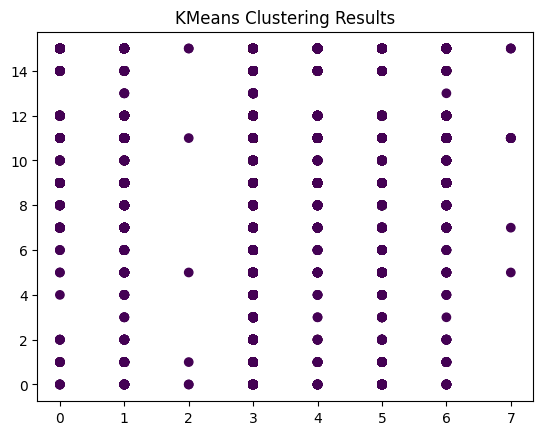

In [22]:
silhouette_avg = silhouette_score(x, labels)
print(f"Silhouette Score: {silhouette_avg}")

print("Inertia:", kmeans.inertia_)


plt.scatter(x.iloc[:, 0], x.iloc[:, 1], c=labels, cmap='viridis')
plt.title("KMeans Clustering Results")
plt.show()
